In [283]:
#### import ####
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
## statsmodels ##
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
## acf, pacf ##
from statsmodels.tsa.stattools import pacf, acf
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.api import VAR
## garch
from arch import arch_model
from statsmodels.tsa.api import VAR
import seaborn as sns
from statsmodels.tsa.vector_ar.vecm import coint_johansen


# Get data

In [215]:
df = pd.read_csv("DS_IPC_PRINC_CSV_FR/DS_IPC_PRINC_data.csv", sep=";")

data_al = df[
    (df['IND_TYPE'] == 'M_VAR') # monthly variation
    & (df['IDX_TYPE'] == 'CPI') # cpi
    & (df['PRODUCT_GROUP'] == "4002") # alimentation s/produits frais
    & (df['GEO'] == 'FM')
]
data_fp = df[
    (df['IND_TYPE'] == 'M_VAR') # monthly variation
    & (df['IDX_TYPE'] == 'CPI') # cpi
    & (df['PRODUCT_GROUP'] == "4001") # produits frais
    & (df['GEO'] == 'FM')
]

data_al_vals = data_al['OBS_VALUE']
data_al_index = data_al['TIME_PERIOD']
data_al_vals.index = pd.to_datetime(data_al_index)

data_fp_vals = data_fp['OBS_VALUE']
data_fp_index = data_fp['TIME_PERIOD']
data_fp_vals.index = pd.to_datetime(data_fp_index)

food = pd.concat([data_al_vals, data_fp_vals], axis=1)
food.columns = ['ASFP', 'FP']

food = food.sort_index()
food.dropna(inplace=True)

C:\Users\José\AppData\Local\Temp\ipykernel_1064\3740099334.py:24: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  food = pd.concat([data_al_vals, data_fp_vals], axis=1)


In [295]:
food.shape

(360, 2)

<Axes: xlabel='TIME_PERIOD'>

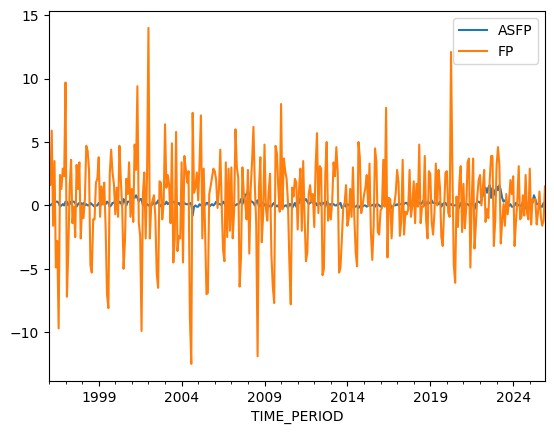

In [216]:
food.plot()

<Axes: xlabel='date'>

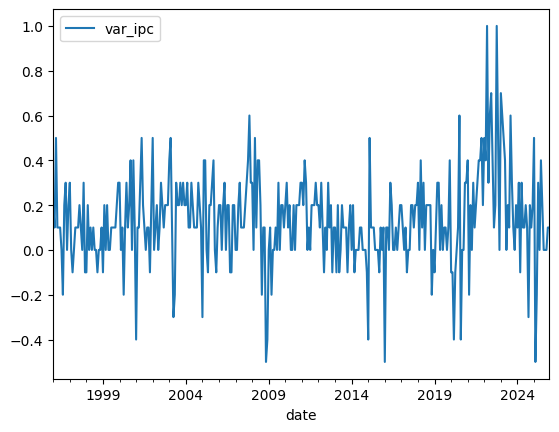

In [217]:
inflation = pd.read_csv('var_ipc.csv')
inflation.index = pd.to_datetime(inflation['date'])
inflation.drop(columns=['date'], inplace=True)
inflation.plot()

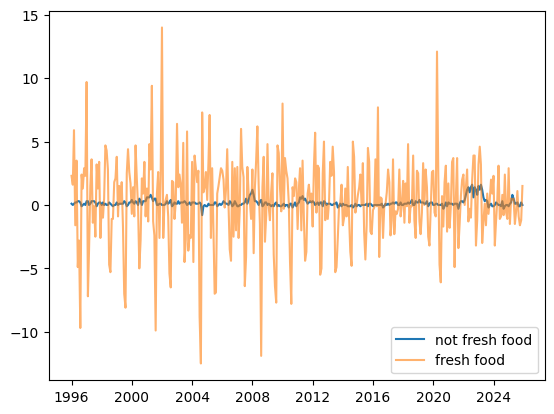

In [294]:
#plt.plot(inflation, label='inflation', alpha = 0.7)
plt.plot(food['ASFP'], label = 'not fresh food')
plt.plot(food['FP'], label = 'fresh food', alpha = 0.6)
plt.legend();

# Test ADF

In [219]:
food.apply(lambda x: adfuller(x)[1]) # p-value

ASFP    1.867874e-04
FP      4.492215e-09
dtype: float64

ASFP    Figure(640x480)
FP      Figure(640x480)
dtype: object

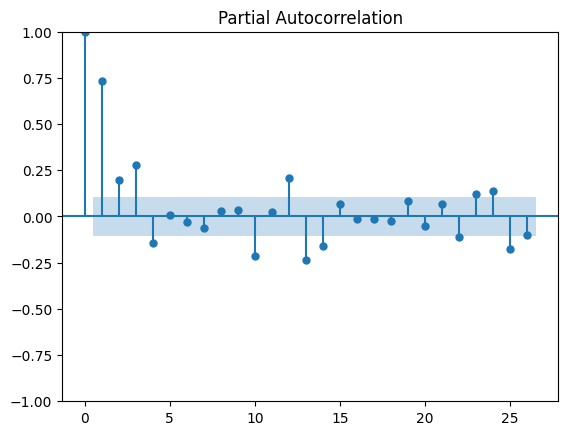

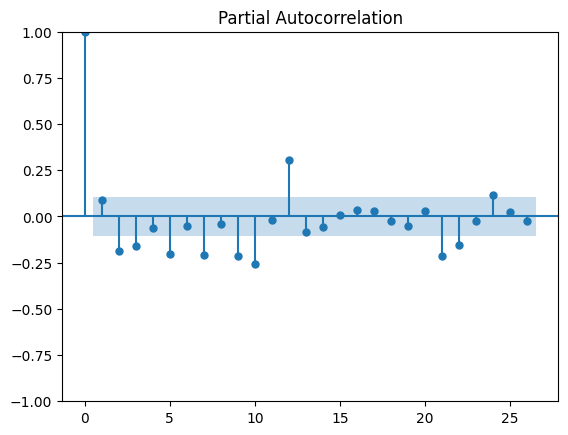

In [220]:
food.apply(plot_pacf)

ASFP    Figure(640x480)
FP      Figure(640x480)
dtype: object

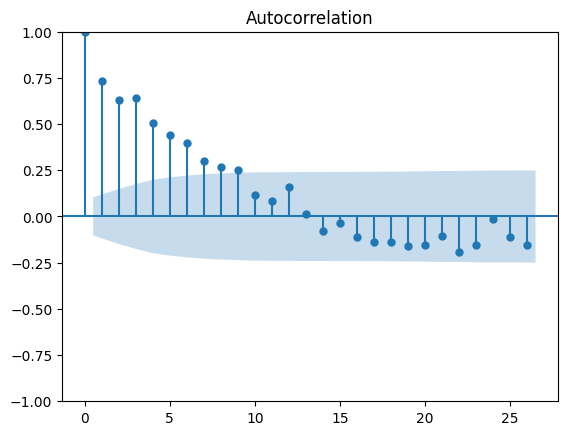

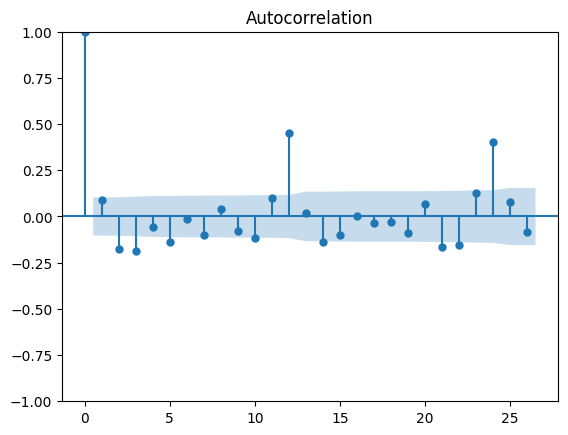

In [221]:
food.apply(plot_acf)

In [222]:
n, _ = food.shape
n

360

In [237]:
var = VAR(food)
var.select_order(maxlags=24).summary()

,AIC,BIC,FPE,HQIC
0,0.01963,0.04235,1.020,0.02869
1,-0.8031,-0.7350,0.4479,-0.7760
2,-0.8961,-0.7825,0.4081,-0.8508
3,-0.9866,-0.8276*,0.3728,-0.9232
4,-1.003,-0.7981,0.3669,-0.9211
5,-1.009,-0.7593,0.3645,-0.9096
6,-1.009,-0.7139,0.3645,-0.8915
7,-1.057,-0.7160,0.3476,-0.9210
8,-1.049,-0.6625,0.3504,-0.8948
9,-1.114,-0.6825,0.3283,-0.9421


<Axes: >

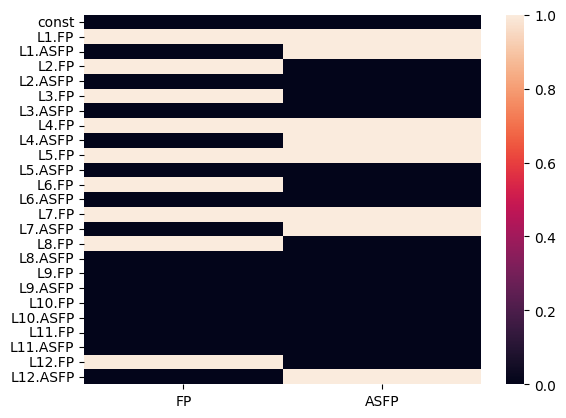

In [228]:
var_fit = var.fit(12)
sns.heatmap(var_fit.pvalues < 0.05)

In [298]:
var_fit.pvalues

,FP,ASFP
const,9.817262e-01,9.595375e-01
L1.FP,4.324361e-05,3.578963e-02
L1.ASFP,4.313964e-01,1.262010e-08
L2.FP,7.845107e-09,3.572106e-01
L2.ASFP,9.769884e-01,5.238548e-02
L3.FP,7.752250e-10,5.141585e-01
L3.ASFP,1.622765e-01,6.872779e-01
L4.FP,5.687943e-12,3.940452e-02
L4.ASFP,1.698324e-01,1.350943e-02
L5.FP,2.451409e-10,1.950322e-02


In [299]:
pd.Series(np.abs(var_fit.roots))

0     1.196186
1     1.196186
2     1.147271
3     1.147271
4     1.112399
5     1.112399
6     1.086946
7     1.086946
8     1.074866
9     1.074866
10    1.070731
11    1.070731
12    1.068290
13    1.068290
14    1.064753
15    1.064753
16    1.063729
17    1.063729
18    1.056891
19    1.056891
20    1.040010
21    1.040010
22    1.036002
23    1.036002
dtype: float64

In [250]:
var_fit.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Apr, 2026
Time:                     22:33:50
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.18338
Nobs:                     348.000    HQIC:                  -3.51651
Log likelihood:          -287.367    FPE:                  0.0238406
AIC:                     -3.73686    Det(Omega_mle):       0.0207519
--------------------------------------------------------------------
Results for equation FP
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.001954         0.085316            0.023           0.982
L1.FP           -0.213572         0.052225           -4.089           0.000
L1.ASFP         -0.698690         0.888010           -0.787           0.431
L2.FP  

In [257]:
var_fit.test_causality(causing='FP', caused='ASFP', kind='f').pvalue

0.020832934063478442

In [300]:
var_fit.test_causality(causing='FP', caused='FP', kind='f').pvalue

1.921616493923048e-29

In [258]:
var_fit.test_causality(causing='ASFP', caused='FP', kind='f').pvalue

0.2908971431537578

In [301]:
var_fit.test_causality(causing='ASFP', caused='ASFP', kind='f').pvalue

1.1772212136101565e-32

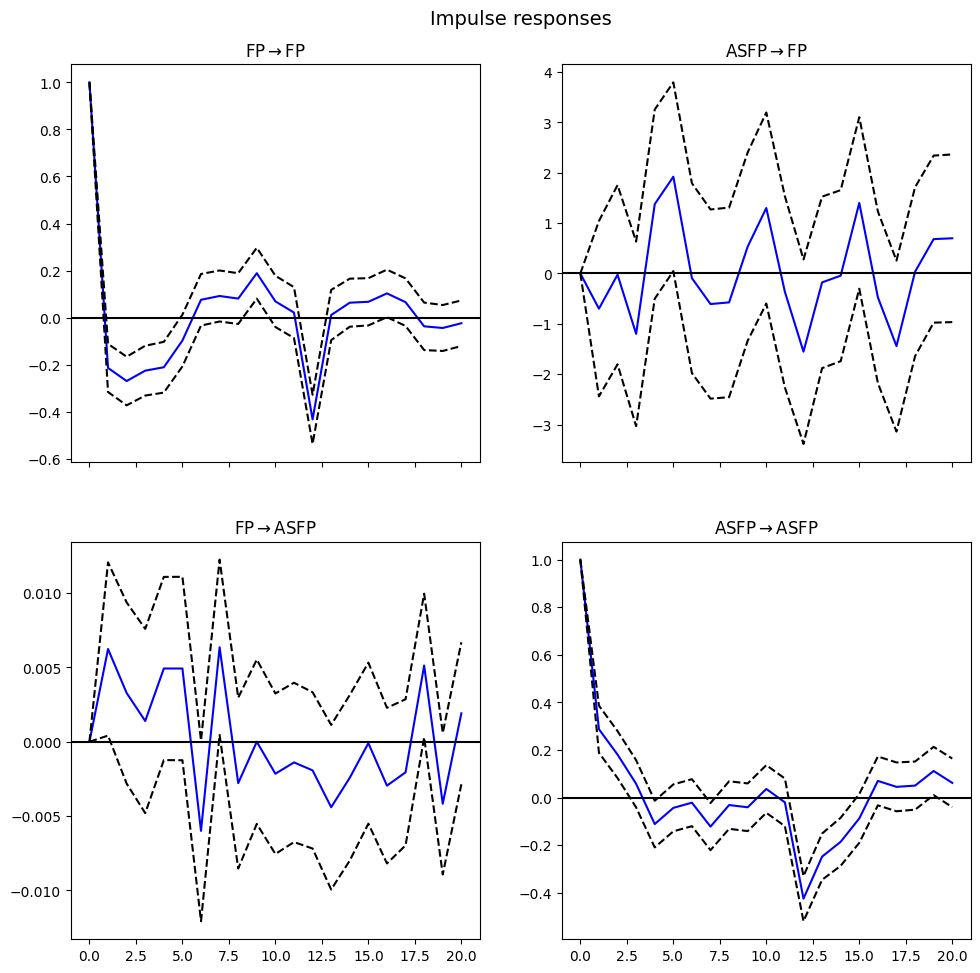

In [263]:
irf = var_fit.irf(periods=20).plot()

FP      Figure(640x480)
ASFP    Figure(640x480)
dtype: object

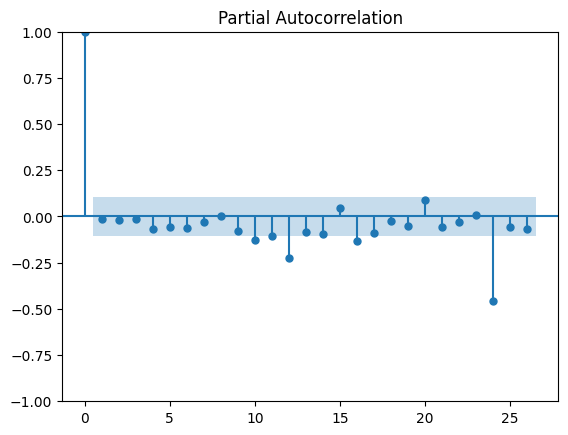

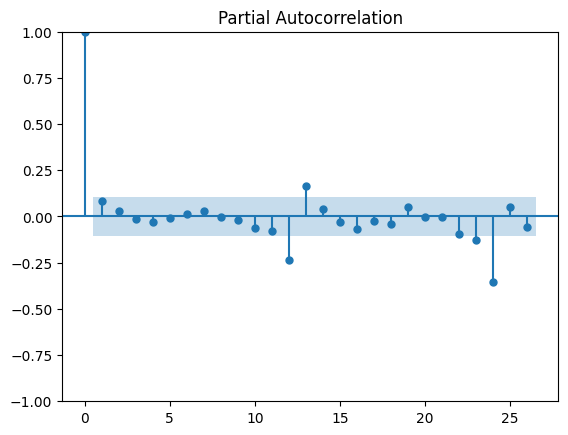

In [282]:
var_fit.resid.apply(plot_pacf)

FP      Figure(640x480)
ASFP    Figure(640x480)
dtype: object

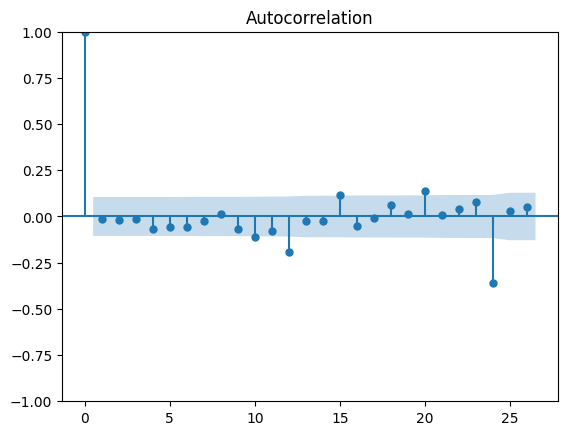

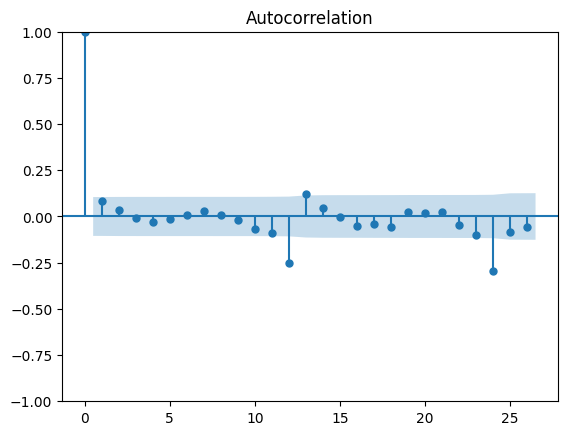

In [281]:
var_fit.resid.apply(plot_acf)

# Cointegration

In [289]:
jres = coint_johansen(food, det_order=0, k_ar_diff=1)
jres.lr1, jres.cvt

(array([216.60720513,  27.77779917]),
 array([[13.4294, 15.4943, 19.9349],
        [ 2.7055,  3.8415,  6.6349]]))

In [ ]:
rank = sum(jres.lr1 > jres.cvt[:,1])
print("Cointegration rank:", rank)

Cointegration rank: 2
